# PJM LMP Forecasting — ARIMA vs ETS (DOM vs AEP)

Demonstrates two classical time-series baselines — ARIMA and ETS (Error/Trend/Seasonal,
the Holt-Winters family) — on daily-average day-ahead LMP, comparing the DOM (Northern
Virginia hyperscale cluster) and AEP (Ohio/WV datacenter corridor) zones.

Run cells top-to-bottom after `01_lmp_explorer.ipynb` has verified the ingest.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sqlalchemy import create_engine
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.arima.model import ARIMA

from config import DB

url = (f"postgresql+psycopg2://{DB['user']}:{DB['password']}"
       f"@{DB['host']}:{DB['port']}/{DB['dbname']}")
engine = create_engine(url)
conn = engine.connect()
print('Connected to', DB['dbname'])

ZONES_HERE = ['DOM', 'AEP']
HOLDOUT_DAYS = 30
SEASONAL_PERIOD = 7  # weekly (weekday/weekend load pattern)

Connected to pjm_pipeline


## 1. Pull & prepare data

Daily-average DA LMP per zone, full history. `asfreq('D')` locks in a complete calendar
index — worth checking for gaps before trusting any seasonal model.

In [2]:
zones_str = ", ".join(f"'{z}'" for z in ZONES_HERE)

daily = pd.read_sql(f"""
    SELECT
        datetime_beginning_utc::date AS day,
        pnode_name,
        AVG(lmp) AS avg_lmp
    FROM pjm_da_lmp
    WHERE pnode_name IN ({zones_str})
    GROUP BY 1, 2
    ORDER BY 1, 2
""", conn, parse_dates=['day'])

piv = daily.pivot(index='day', columns='pnode_name', values='avg_lmp')
piv = piv.asfreq('D')

print(f"Range: {piv.index.min().date()} → {piv.index.max().date()}  ({len(piv)} days)")
print(f"Missing values per zone:\n{piv.isna().sum()}")
piv.tail()

Range: 2022-01-01 → 2026-08-17  (1690 days)
Missing values per zone:
pnode_name
AEP    0
DOM    0
dtype: int64


pnode_name,AEP,DOM
day,,
2026-08-13,51.568021,60.615458
2026-08-14,49.366546,55.141112
2026-08-15,49.294358,56.037604
2026-08-16,51.043033,58.006646
2026-08-17,68.962150,78.397850


## 2. EDA

DOM carries a visibly higher mean and much fatter tail than AEP — consistent with
`config.py`'s description of DOM as the hyperscale-cluster zone (congestion premium from
concentrated datacenter load) vs AEP's flatter corridor profile. That volatility gap is
the reason to expect different forecastability between the two zones below.

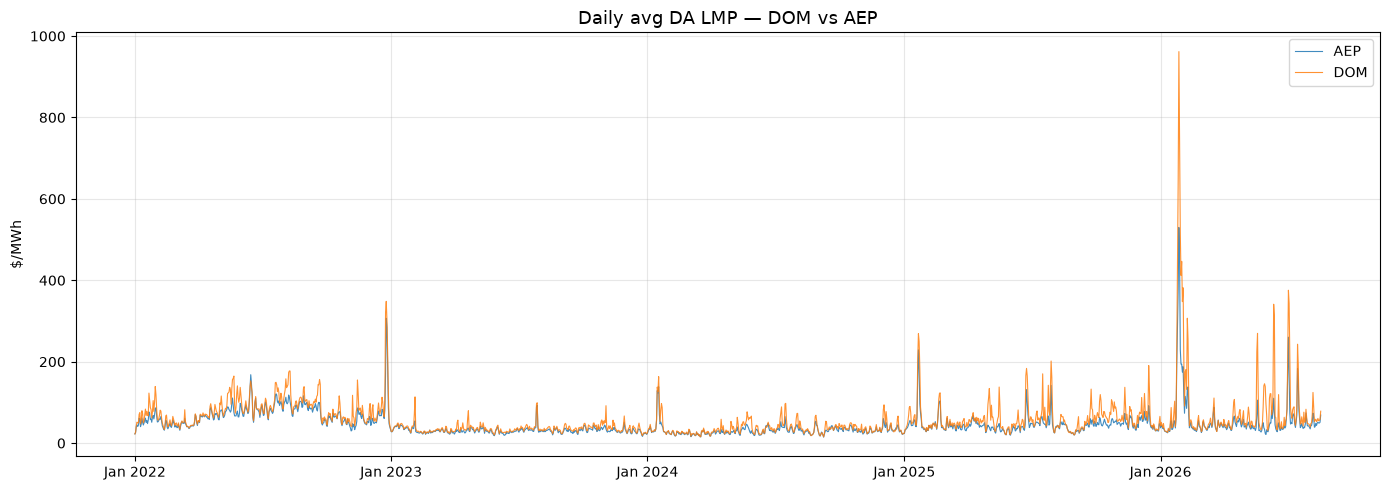

pnode_name,AEP,DOM
count,1690.000000,1690.000000
mean,46.626701,58.986225
std,32.334449,53.908413
min,14.732917,15.335437
25%,29.853399,33.463381
50%,38.052542,44.475156
75%,51.897263,67.109419
max,529.731487,961.744979


In [3]:
fig, ax = plt.subplots(figsize=(14, 5))
for zone in piv.columns:
    ax.plot(piv.index, piv[zone], label=zone, linewidth=0.8, alpha=0.85)

ax.set_title('Daily avg DA LMP — DOM vs AEP', fontsize=13)
ax.set_ylabel('$/MWh')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

piv.describe()

In [4]:
print("Augmented Dickey-Fuller test (H0: unit root / non-stationary)\n")
adf_d = {}
for zone in ZONES_HERE:
    stat, pvalue, *_ = adfuller(piv[zone].dropna())
    adf_d[zone] = 0 if pvalue < 0.05 else 1
    verdict = 'stationary' if pvalue < 0.05 else 'non-stationary'
    print(f"{zone}: ADF stat={stat:7.2f}  p-value={pvalue:.4f}  -> {verdict} (d={adf_d[zone]})")

Augmented Dickey-Fuller test (H0: unit root / non-stationary)

DOM: ADF stat=  -6.37  p-value=0.0000  -> stationary (d=0)
AEP: ADF stat=  -5.25  p-value=0.0000  -> stationary (d=0)


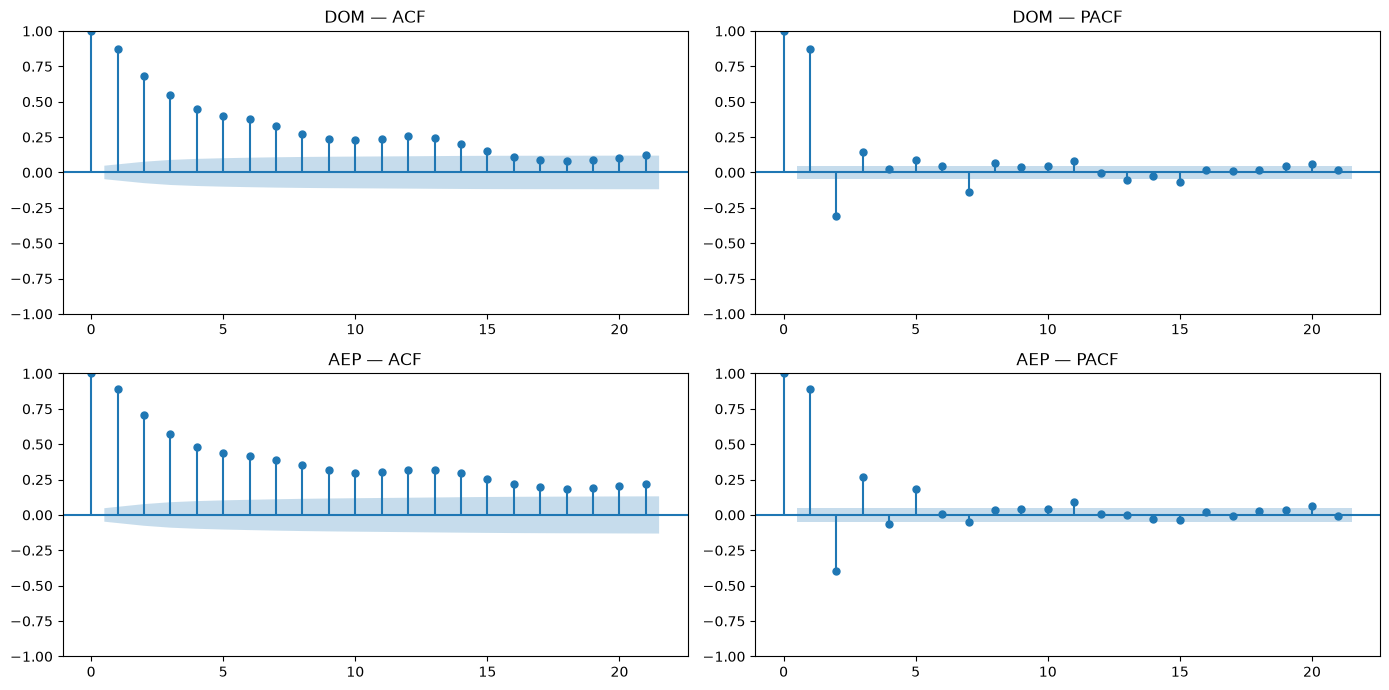

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for row, zone in enumerate(ZONES_HERE):
    plot_acf(piv[zone].dropna(), lags=21, ax=axes[row, 0], title=f'{zone} — ACF')
    plot_pacf(piv[zone].dropna(), lags=21, ax=axes[row, 1], method='ywm', title=f'{zone} — PACF')
plt.tight_layout()
plt.show()

## 3. Train / holdout split

Holdout = last 30 days. Note: for this data snapshot that window (mid-June – July 13,
2026) overlaps the July 4th holiday-weekend heat-demand spike documented in the pipeline's
own operating notes (AEP DA LMP hit ~$1,133/MWh) — a real market event, not a data bug.
Expect both models to under-forecast that window; it's a useful illustration of exactly
the limits discussed in section 7 below, not a modeling failure.

In [6]:
train = piv.iloc[:-HOLDOUT_DAYS]
test = piv.iloc[-HOLDOUT_DAYS:]
print(f"Train: {train.index.min().date()} → {train.index.max().date()}  ({len(train)} days)")
print(f"Test:  {test.index.min().date()} → {test.index.max().date()}  ({len(test)} days)")

Train: 2022-01-01 → 2026-07-18  (1660 days)
Test:  2026-07-19 → 2026-08-17  (30 days)


## 4. ETS baseline

`ETSModel` fit per zone as ETS(M,N,M) — multiplicative error, no trend, multiplicative
weekly seasonal. Multiplicative form fits an always-positive series like LMP where swings
scale with the price level, per the ETS taxonomy note in the GEEKOM wiki.

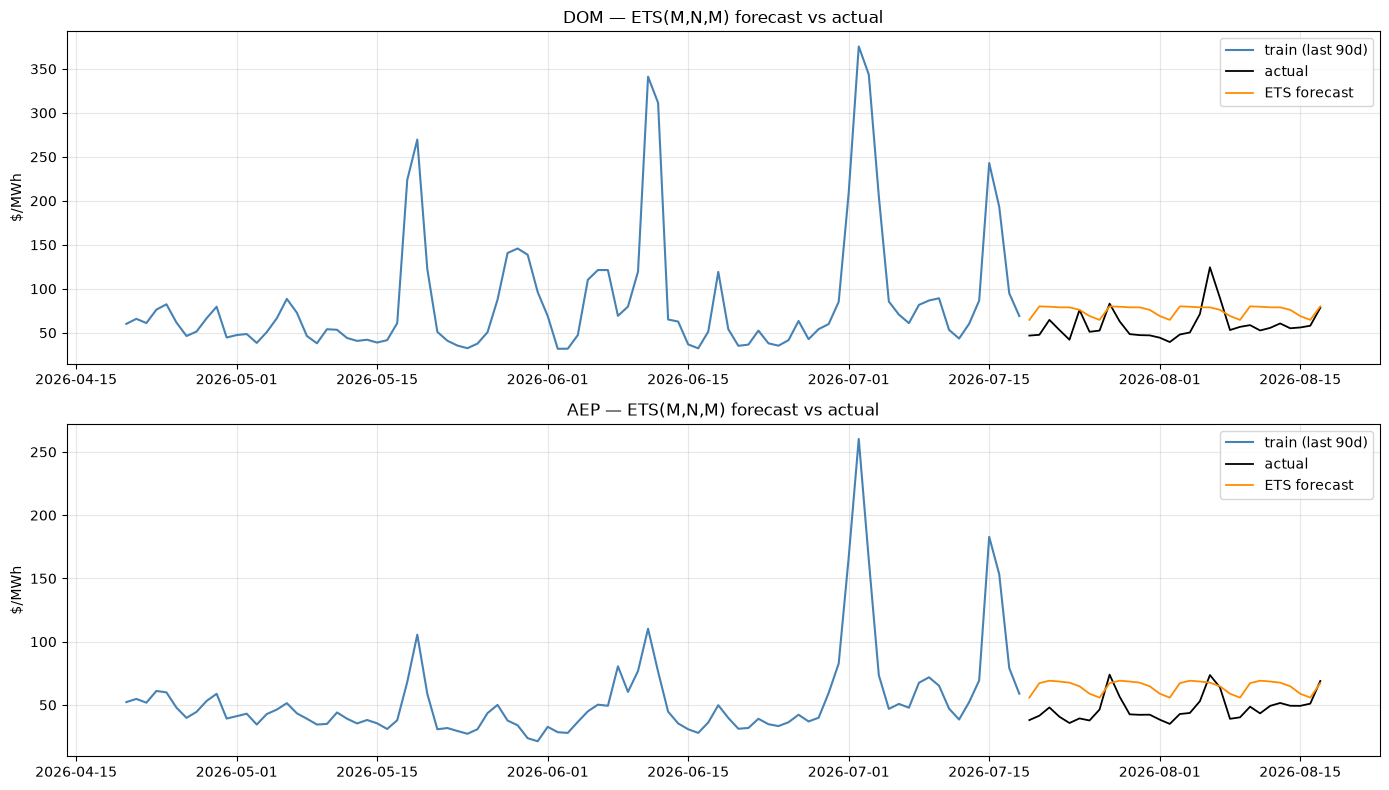

In [7]:
ets_results = {}
ets_forecasts = {}

for zone in ZONES_HERE:
    fit = ETSModel(train[zone], error='mul', trend=None, seasonal='mul',
                    seasonal_periods=SEASONAL_PERIOD).fit(disp=False)
    fc = fit.forecast(HOLDOUT_DAYS)
    ets_results[zone] = fit
    ets_forecasts[zone] = fc

fig, axes = plt.subplots(len(ZONES_HERE), 1, figsize=(14, 8), sharex=False)
for ax, zone in zip(axes, ZONES_HERE):
    recent = train[zone].iloc[-90:]
    ax.plot(recent.index, recent.values, label='train (last 90d)', color='steelblue')
    ax.plot(test.index, test[zone].values, label='actual', color='black', linewidth=1.3)
    ax.plot(test.index, ets_forecasts[zone].values, label='ETS forecast', color='darkorange', linewidth=1.3)
    ax.set_title(f'{zone} — ETS(M,N,M) forecast vs actual')
    ax.set_ylabel('$/MWh')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. ARIMA baseline

Small grid search over `(p, q)` by AIC (statsmodels `ARIMA`, not `pmdarima` — a manual
grid is plenty for two zones and avoids an extra, less-actively-maintained dependency).
`d` comes from the ADF test above; a fixed weekly seasonal term `(1,0,1,7)` is included
since plain ARIMA has no seasonal component of its own and the ACF/PACF plots show a
clear 7-day echo.

/home/daniel/projects/pjm_pipeline/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/daniel/projects/pjm_pipeline/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/daniel/projects/pjm_pipeline/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/daniel/projects/pjm_pipeline/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization fail

DOM: best order=(2, 0, 2)  seasonal_order=(1,0,1,7)  AIC=15366.5


/home/daniel/projects/pjm_pipeline/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/daniel/projects/pjm_pipeline/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


AEP: best order=(2, 0, 2)  seasonal_order=(1,0,1,7)  AIC=13175.6


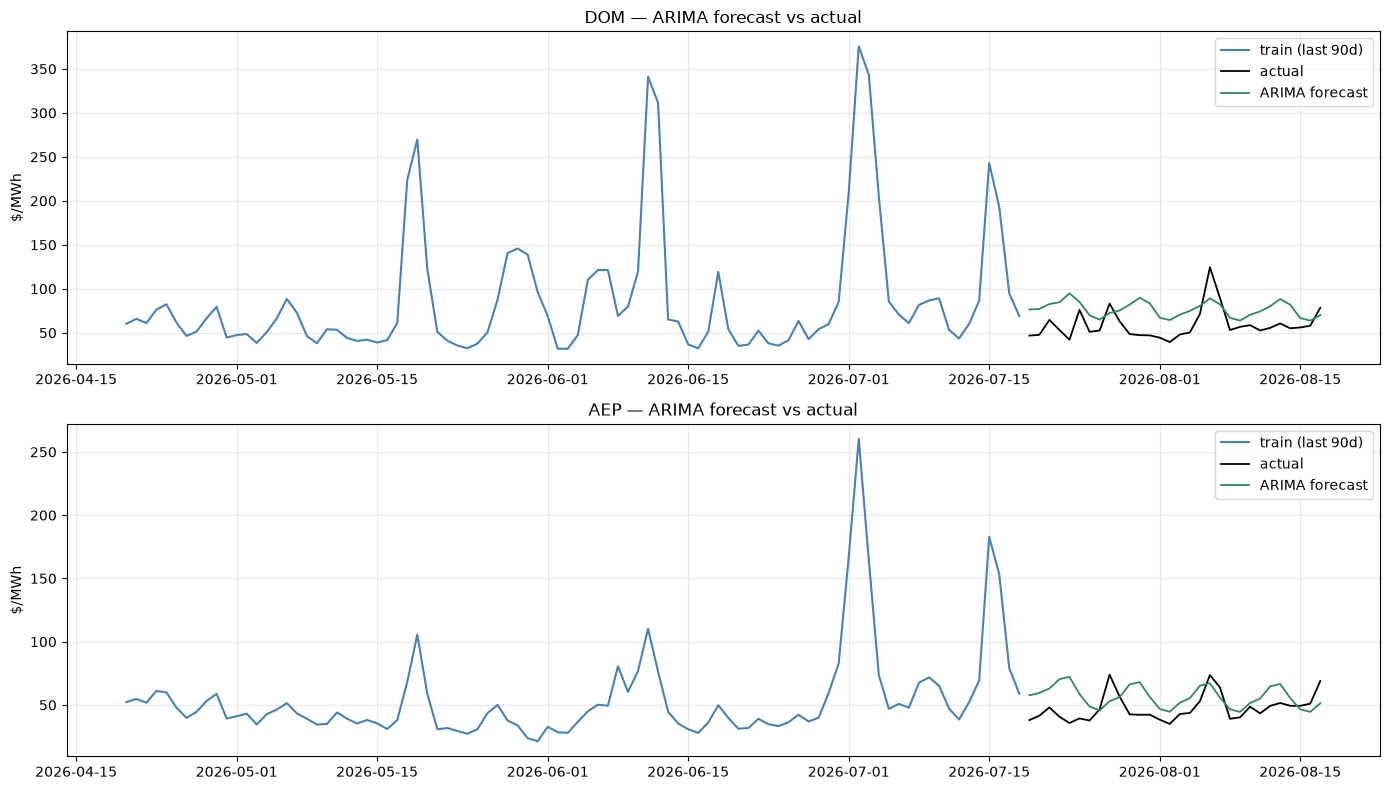

In [8]:
arima_results = {}
arima_forecasts = {}

for zone in ZONES_HERE:
    d = adf_d[zone]
    best_aic, best_order = np.inf, None
    for p in range(3):
        for q in range(3):
            try:
                fit = ARIMA(train[zone], order=(p, d, q), seasonal_order=(1, 0, 1, SEASONAL_PERIOD)).fit()
                if fit.aic < best_aic:
                    best_aic, best_order = fit.aic, (p, d, q)
            except Exception:
                continue
    fit = ARIMA(train[zone], order=best_order, seasonal_order=(1, 0, 1, SEASONAL_PERIOD)).fit()
    fc = fit.forecast(HOLDOUT_DAYS)
    arima_results[zone] = fit
    arima_forecasts[zone] = fc
    print(f"{zone}: best order={best_order}  seasonal_order=(1,0,1,{SEASONAL_PERIOD})  AIC={best_aic:.1f}")

fig, axes = plt.subplots(len(ZONES_HERE), 1, figsize=(14, 8), sharex=False)
for ax, zone in zip(axes, ZONES_HERE):
    recent = train[zone].iloc[-90:]
    ax.plot(recent.index, recent.values, label='train (last 90d)', color='steelblue')
    ax.plot(test.index, test[zone].values, label='actual', color='black', linewidth=1.3)
    ax.plot(test.index, arima_forecasts[zone].values, label='ARIMA forecast', color='seagreen', linewidth=1.3)
    ax.set_title(f'{zone} — ARIMA forecast vs actual')
    ax.set_ylabel('$/MWh')
    ax.legend()
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Comparison table

MAE / RMSE / MAPE for each {method × zone}, computed against the 30-day holdout.

In [9]:
def error_metrics(actual, forecast):
    actual, forecast = np.asarray(actual), np.asarray(forecast)
    mae = np.mean(np.abs(forecast - actual))
    rmse = np.sqrt(np.mean((forecast - actual) ** 2))
    mape = np.mean(np.abs((forecast - actual) / actual)) * 100
    return mae, rmse, mape

rows = []
for zone in ZONES_HERE:
    for method, fc in [('ETS', ets_forecasts[zone]), ('ARIMA', arima_forecasts[zone])]:
        mae, rmse, mape = error_metrics(test[zone], fc)
        rows.append({'zone': zone, 'method': method, 'MAE': mae, 'RMSE': rmse, 'MAPE_%': mape})

summary = pd.DataFrame(rows).set_index(['zone', 'method'])
summary.style.format('{:.2f}')

## 7. Discussion — baselines vs. the forward curve

ARIMA and ETS are exactly the fast, defensible statistical baselines described in the
GEEKOM wiki's Electrify America interview-prep note (`2026-07-16-electrify-america-application.md`):
seconds to fit, no feature engineering, and — per the M-competition literature cited
there — hard to meaningfully beat with something heavier unless there's specific evidence
the simpler stack is leaving accuracy on the table.

But that note also raises a sharper point that this notebook's own holdout window
illustrates directly: both models under-forecast the July 2026 heat-demand spike (section
3), because **a statistical model trained on the past has no way to see a future weather
shock coming** — it can only extrapolate the patterns already in its training window.
That's fine for *load/price-shape* forecasting (weekly seasonality, mean-reversion, the
kind of thing modeled here), but it's the wrong tool for a genuinely tradeable price
level. For that, the desk principle from the same note applies: **read the forward
curve, don't forecast it** — PJM's on/off-peak monthly blocks (explored in
`01_lmp_explorer.ipynb`'s on/off-peak section, instruments mapped in GEEKOM's
`2026-06-30-pjm-futures-gemini` note) already embed the market's own weather- and
event-risk premium, priced by capital, at the liquid points where that market exists.

Correct architecture for a real deployment, then, splits the problem the way that note
does:

- **Load / price-shape** (what's modeled here): no market for it — ARIMA/ETS/boosted
  trees legitimately live here.
- **Price at liquid points**: taken from the forward curve, not extrapolated.
- **Residual**: the statistical layer's real job is the *spread* — hourly shape and
  nodal basis between a liquid hub and the delivery point — not the price level itself.

DOM vs AEP is a useful pairing for this exact caveat: DOM's fatter tail (higher mean,
far higher max — see section 2) means a naive statistical extrapolation is *more* wrong,
more often, precisely in the highest-congestion, most datacenter-relevant zone — the one
where getting the cost number right matters most.